In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

import torch
import torch.nn as nn

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from torch.utils.data import TensorDataset, DataLoader

Check whether google colab kernel is used

In [2]:
import sys 

IN_COLAB = 'google.colab' in sys.modules
IN_COLAB

False

#### Download Data

In [5]:
if IN_COLAB:
    import urllib.request

    base_url = "https://raw.githubusercontent.com/atleer/forecast-electricity-markets/main/data/processed/opsd-time_series-2020-10-06"
    splits = ['train', 'validation', 'test']
    filename = 'time_series_60min_singleindex.parquet'

    for split in splits:
        dir_path = f"data/processed/opsd-time_series-2020-10-06/{split}"
        os.makedirs(dir_path, exist_ok=True)
        url = f"{base_url}/{split}/{filename}"
        dest = f"{dir_path}/{filename}"
        urllib.request.urlretrieve(url, dest)
        print(f"Downloaded {split}")

    root_dir = Path('.')

    

In [14]:
if IN_COLAB:
    root_dir = Path('.')
else:
    notebook_path = %pwd
    root_dir = Path(notebook_path).parent.parent.parent

Set seed and turn of non-deterministic behavior for reproducibility

In [16]:
SEED = 2026

def set_seed(seed: int = 2026) -> None:
    """Set seed and disable non-deterministic behavior for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

Set device

In [17]:
def set_device(device: str = 'cpu') -> str:
    """Set device to CUDA if available. Set to cpu if not."""
    if torch.cuda.is_available():
        device = 'cuda'
    else:
        device = 'cpu'
    return device

device = set_device()

Load Processed Data

In [18]:
processed_data_dir = root_dir / 'data/processed/opsd-time_series-2020-10-06'
filepaths = list(processed_data_dir.glob('**/*60*.parquet'))

for filepath in filepaths:
    if 'train' in filepath.parts:
        df_train = pd.read_parquet(filepath)
    elif 'validation' in filepath.parts:
        df_val = pd.read_parquet(filepath)
    elif 'test' in filepath.parts:
        df_test = pd.read_parquet(filepath)

Choose columns to use in data

In [19]:
features_column_names = ['DE_wind_generation', 'DE_price_ahead']
targets_column_names = ['DE_price_ahead']

Scale data

Open question: Should I use different scaling than standardization with mean?

In [20]:
features_mean = df_train[features_column_names].mean(axis=0).values
targets_mean = df_train[targets_column_names].mean(axis=0).values

features_std = df_train[features_column_names].std(axis=0).values
targets_std = df_train[targets_column_names].std(axis=0).values


In [21]:
features_train = ((df_train[features_column_names].values - features_mean)/features_std)
features_val = ((df_val[features_column_names].values - features_mean)/features_std)
features_test = ((df_test[features_column_names].values - features_mean)/features_std)

targets_train = ((df_train[targets_column_names].values - targets_mean)/targets_std)
targets_val = ((df_val[targets_column_names].values - targets_mean)/targets_std)
targets_test = ((df_test[targets_column_names].values - targets_mean)/targets_std)

## Forecast price ahead using both historical price data and wind generation

Create sequences

In [22]:
def create_sequences(features, targets, input_len: int = 48, horizon: int = 24):
    """Create sequences for seq2seq forecasting
    
    Args:
        features: data to use in forecast
        targets: data to forecast
        input_len: past timesteps to use in forecast (encoder window length)
        horizon: future timesteps to forecast (decoder window length)

    Returns:
        X: (n_samples, input_len, n_features) inputs to encoder
        y: (n_samples, horizon, n_targets) targets (labels) for decoder
    """

    n_samples = len(features)

    X = np.empty((n_samples - input_len - horizon, input_len, features.shape[-1]))
    y = np.empty((n_samples - input_len - horizon, horizon, targets.shape[-1]))

    for i_sample in range(n_samples - input_len - horizon):
        for i_feature in range(features.shape[-1]):
            X[i_sample,:,i_feature] = features[i_sample:(i_sample + input_len), i_feature]

        for i_feature in range(targets.shape[-1]):
            y[i_sample,:,i_feature] = targets[(i_sample + input_len):(i_sample + input_len + horizon), i_feature]

    return np.array(X), np.array(y)

In [23]:
input_len = 48
horizon = 24

In [37]:
if targets_train.ndim == 1:
    targets_train = np.expand_dims(targets_train, axis=-1)
    targets_val = np.expand_dims(targets_val, axis=-1)
    targets_test = np.expand_dims(targets_test, axis=-1)

X_train, y_train = create_sequences(features_train, targets_train, input_len, horizon)
X_val, y_val = create_sequences(features_val, targets_val, input_len, horizon)
X_test, y_test = create_sequences(features_test, targets_test, input_len, horizon)

X_train = torch.from_numpy(X_train).to(dtype = torch.float32, device=device)
y_train = torch.from_numpy(y_train).to(dtype = torch.float32, device=device)

X_val = torch.from_numpy(X_val).to(dtype = torch.float32, device=device)
y_val = torch.from_numpy(y_val).to(dtype = torch.float32, device=device)

X_test = torch.from_numpy(X_test).to(dtype = torch.float32, device=device)
y_test = torch.from_numpy(y_test).to(dtype = torch.float32, device=device)

Create DataLoaders

In [54]:
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=True)

Create Seq2Seq Model

In [55]:
class Seq2SeqGRU(nn.Module):
    def __init__(self, enc_input_size: int = 2, dec_input_size: int = 1, hidden_size: int = 64, num_layers: int = 1,):
        super().__init__()
        self.encoder = nn.GRU(input_size=enc_input_size, hidden_size=hidden_size, batch_first=True, device=device)
        self.decoder = nn.GRU(input_size=dec_input_size, hidden_size=hidden_size, batch_first=True, device=device)
        self.fc = nn.Linear(hidden_size, dec_input_size, device=device)

    def forward(self, X: torch.Tensor, horizon: int, y_teacher: torch.Tensor | None = None, teacher_threshold: float = 0.5):

        # encode input
        enc_output, hidden = self.encoder(X)
        #print(f'enc_output.shape: {enc_output.shape}')

        #print(f'encoder hidden.shape: {hidden.shape}')

        # seed for decoder: the last observed price
        # TODO: Can't this be y? Check
        dec_input = X[:, -1:, 1:2] # dims: (batch, 1, 1)

        #print(f'X.shape: {X.shape}, dec_input.shape: {dec_input.shape}')

        predictions = []
        for time_step in range(horizon):
            # decode
            dec_output, hidden = self.decoder(dec_input, hidden)
            #print(f'dec_output: {dec_output.shape}, decoder hidden.shape: {hidden.shape}')

            # make prediction from output of decoder
            prediction = self.fc(dec_output)
            #print(f'prediction.shape: {prediction.shape}')
            predictions.append(prediction)

            apply_teacher_forcing = (y_teacher is not None 
                                     and torch.rand(1).item() < teacher_threshold)

            if apply_teacher_forcing:
                dec_input = y_teacher[:, time_step:time_step+1].unsqueeze(1)
            else:
                dec_input = prediction


        # concatinate over dim 1 so that horizon is on second dimension and batches on first
        return torch.cat(predictions, dim=1)

Train

In [56]:
def train(model: nn.Module, dataloader: DataLoader, horizon: int, optimizer: torch.optim.Optimizer, criterion = nn.MSELoss(), nepochs: int = 50):
    """Train a neural network model

    Args:
        model: Model to train.
        dataloader: dataloader containing features and targets
        horizon: number of time steps into the future to forecast
        optimizer: optimization algorithm
        criterion: loss function
        nepochs: Number of training epochs

    Returns:
        A tuple of (losses, accuracies). Each is a list of values recorded
        at each epoch during training.
    """


    losses = []
    for epoch in tqdm(range(nepochs)):
        for batch_idx, (X_batch, y_batch) in enumerate(dataloader):
            optimizer.zero_grad()

            predictions = model(X_batch, horizon=horizon)

            loss = criterion(predictions, y_batch)

            loss.backward()

            optimizer.step()

            losses.append(loss.item())

        if (epoch % 10) == 0:
            print(f'epoch: {epoch}, loss: {loss.item():.3f}')

    return losses

In [76]:
def train_with_early_stopping(model: nn.Module, 
                              train_dataloader: DataLoader,
                              val_dataloader: DataLoader,
                              horizon: int, 
                              optimizer: torch.optim.Optimizer, 
                              criterion = nn.MSELoss(), 
                              max_epochs: int = 100,
                              patience: int = 30):
    """Train a neural network model with early stopping

    Args:
        model: Model to train.
        dataloader: dataloader containing features and targets
        horizon: number of time steps into the future to forecast
        optimizer: optimization algorithm
        criterion: loss function
        max_epochs: Maximal number of training epochs
        patience: Number of training epochs to wait until you stop training due to no improvement on validation loss

    Returns:
        A tuple of (losses, accuracies). Each is a list of values recorded
        at each epoch during training.
    """
    losses_val = []
    for (X_val_batch, y_val_batch) in val_dataloader:
        y_pred_val = model(X_val_batch, horizon=horizon)
        losses_val.append(criterion(y_pred_val, y_val_batch).item())
    best_loss_val = np.mean(losses_val)
    wait = 0
    stopped_epoch = max_epochs

    losses_train = []
    losses_val = []
    for epoch in tqdm(range(max_epochs)):
        batch_losses = []
        for (X_batch, y_batch) in train_dataloader:
            optimizer.zero_grad()

            predictions = model(X_batch, horizon=horizon)

            loss = criterion(predictions, y_batch)

            loss.backward()

            optimizer.step()

            batch_losses.append(loss.item())

        losses_train.append(np.mean(batch_losses))

        if (epoch % 10) == 0:
            print(f'epoch: {epoch}, loss: {loss.item():.3f}')


        losses_val_temp = []
        for (X_val_batch, y_val_batch) in val_dataloader:
            y_pred_val = model(X_val_batch, horizon=horizon)
            losses_val.append(criterion(y_pred_val, y_val_batch).item())
        loss_val = np.mean(losses_val_temp)
        losses_val.append(loss_val)

        if loss_val < best_loss_val:
            best_loss_val = loss_val
            wait = 0
        else:
            wait += 1

        if wait > patience:
            stopped_epoch = epoch
            break

    return losses_train, losses_val, stopped_epoch

In [ ]:
learning_rates = [0.01, 0.001]
max_epochs = 1

criterion = nn.MSELoss()

model = Seq2SeqGRU(enc_input_size=2, dec_input_size = 1)
model.eval()
y_pred_val = model(X_val, horizon = horizon)
best_loss_val = criterion(y_pred_val, y_val)

for learning_rate in learning_rates:

    model = Seq2SeqGRU(enc_input_size=2, dec_input_size = 1)
    model.train()

    optimizer = torch.optim.Adam(lr = learning_rate, params=model.parameters())

    losses_train, losses_val, stopped_epoch = train_with_early_stopping(model, 
                                                    train_dataloader, 
                                                    val_dataloader,
                                                    horizon = 24, 
                                                    optimizer = optimizer, 
                                                    max_epochs=max_epochs
                                                )

    model.eval()
    y_pred_val = model(X_val, horizon = horizon)

    loss_val = criterion(y_pred_val, y_val)

    if  loss_val < best_loss_val:
        best_loss_val = loss_val
        best_learning_rate = learning_rate
        best_hyper_parameters = {
            'learning_rate': learning_rate
        }

        torch.save({
            "stopped_epoch": stopped_epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_validation": best_loss_val,
        }, 'checkpoint.pth')




  0%|          | 0/1 [00:00<?, ?it/s]

epoch: 0, loss: 0.520


/home/atleeri/repositories/forecast-electricity-markets/.pixi/envs/default/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/atleeri/repositories/forecast-electricity-markets/.pixi/envs/default/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 0/1 [00:00<?, ?it/s]

epoch: 0, loss: 0.672


100%|██████████| 1/1 [00:08<00:00,  8.34s/it]


In [82]:
losses_val, losses_train

([0.8546496629714966, np.float64(nan)], [np.float64(0.8483459514876207)])

Plot forecast on training data

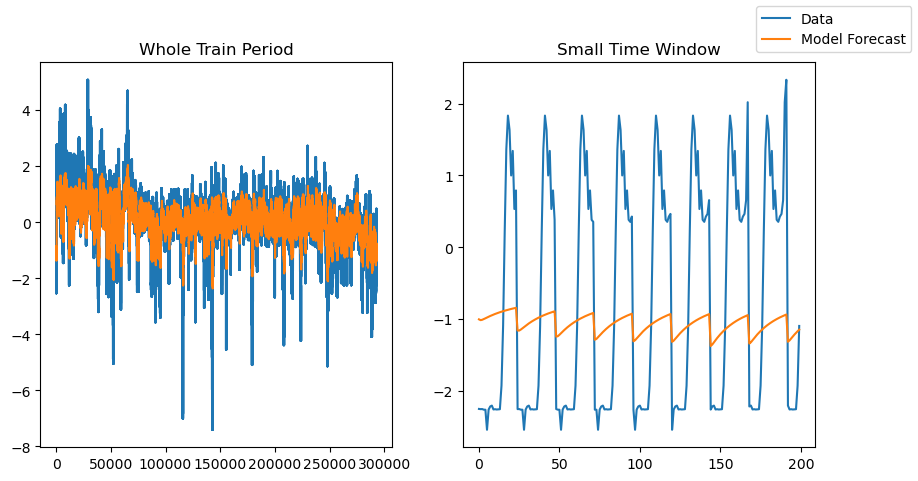

In [79]:
y_pred_train = model(X_train, horizon = horizon)

fig, axes = plt.subplots(ncols = 2, figsize = (10, 5))

axes[0].set_title('Whole Train Period')
axes[0].plot(y_train.cpu().numpy().flatten(), label = 'Data')
with torch.no_grad():
    axes[0].plot(y_pred_train.cpu().numpy().flatten(), label = 'Model Forecast')

window_start = 0
window_end = window_start + 200
axes[1].set_title('Small Time Window')
axes[1].plot(y_train.cpu().numpy().flatten()[window_start:window_end])
with torch.no_grad():
    axes[1].plot(y_pred_train.cpu().numpy().flatten()[window_start:window_end])

fig.legend();

Test

In [43]:
X_test = torch.tensor(X_test, dtype = torch.float32, device=device)
y_test = torch.tensor(y_test, dtype = torch.float32, device=device)

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test, horizon = 24)


/tmp/ipykernel_1161/2762229588.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype = torch.float32, device=device)
/tmp/ipykernel_1161/2762229588.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype = torch.float32, device=device)


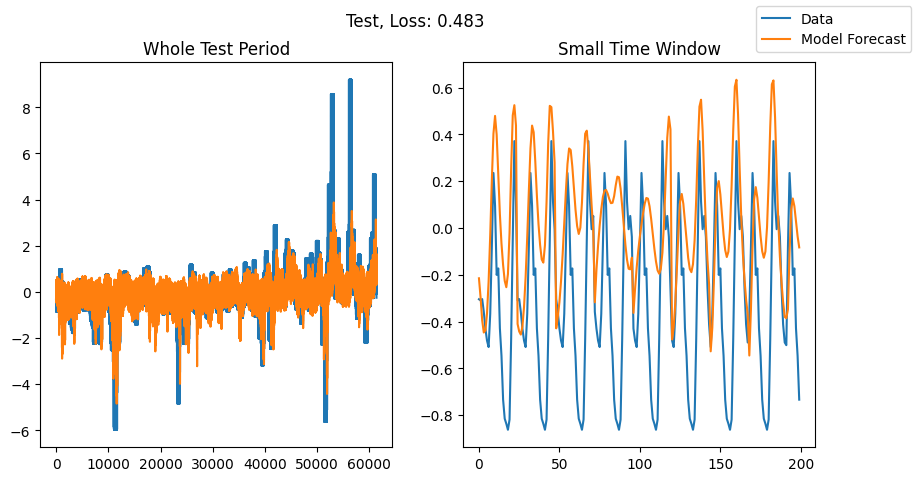

In [44]:
fig, axes = plt.subplots(ncols = 2, figsize = (10, 5))

axes[0].set_title('Whole Test Period')
axes[0].plot(y_test.cpu().numpy().flatten(), label = 'Data')
axes[0].plot(y_pred_test.cpu().numpy().flatten(), label = 'Model Forecast')

test_loss = torch.mean((y_test - y_pred_test)**2).item()
fig.suptitle(f'Test, Loss: {test_loss:.3f}')

axes[1].set_title('Small Time Window')
window_start = 0
window_end = window_start + 200
axes[1].plot(y_test.cpu().numpy().flatten()[window_start:window_end])
axes[1].plot(y_pred_test.cpu().numpy().flatten()[window_start:window_end])

fig.legend();

In [25]:
X_train.shape

torch.Size([12206, 48, 2])

In [ ]:

# ── Evaluate on test set ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test, horizon = 24)

# Denormalise back to original price scale
y_pred_real = y_pred_test.cpu().numpy() * targets_std.values + targets_mean.values
y_test_real = y_test.cpu().numpy() * targets_std.values + targets_mean.values  # already in original scale

mse_mv = ((y_pred_real - y_test_real) ** 2).mean()
print(f"Test MSE (€/MWh)²: {mse_mv:.2f}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full multistep forecast for one test sample
sample_idx = 0
ax = axes[0]
ax.plot(range(horizon), y_test_real[sample_idx], marker='o', label='True')
ax.plot(range(horizon), y_pred_real[sample_idx], marker='x', linestyle='--', label='Predicted')
ax.set_xlabel('Forecast horizon (hours)')
ax.set_ylabel('Price (€/MWh)')
ax.set_title(f'Multistep forecast – test sample {sample_idx}')
ax.legend()

# Right: first-step (h+1) predictions over a slice of the test set
ax = axes[1]
N_plot = 200
ax.plot(y_test_real[:N_plot, 0], label='True (h+1)')
ax.plot(y_pred_real[:N_plot, 0], linestyle='--', label='Predicted (h+1)')
ax.set_xlabel('Test sample index')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('One-step-ahead predictions over test set')
ax.legend()

plt.tight_layout()
plt.show()
